# Fit nonlinear function to network performance

This script takes in the results from data-overview.ipynb, and performs a regression to extract the impact of different regulatory parameters on the data.

In [1]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.backends.backend_pdf import PdfPages

import matplotlib as mpl
import matplotlib.ticker as ticker

import numpy as np
import pandas as pd
import os
import plotly.graph_objects as go
import plotly.express as px
import pickle
import time

# import clustering packages
from sklearn.linear_model import LinearRegression
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import DotProduct, WhiteKernel
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline, interp1d
from scipy.signal import savgol_filter

plt.style.use('custom.mplstyle')
%config InlineBackend.figure_format = 'retina'
from tqdm import tqdm
from joblib import Parallel, delayed

from stoch_sim_model import *

In [2]:
# Load data from 2nd infections
reg_model = ''
runs = '-1-'
comment = "acute_all-sparse-reg"
d = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'
d_mean = '/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/processed_data'+runs+'runs'+'-'+comment+'.pkl'

# Import datasets
clustered_mean_df = pd.read_pickle(d_mean)
with open('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/list_processed_data'+runs+'runs'+'-'+comment+'.pkl', 'rb') as f:
    infection_scenarios = pickle.load(f)

with pd.option_context('display.max_columns', None):
    display(clustered_mean_df)

,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,d_I,K_I,b_I,K_H,N_0,S_0,I_0,d_S,harm_pI,harm_pS,max_eM_fold,frac_cM,log_T_pEcyteM,T_min_pI,T_max_pI,T_pE_start,T_pE_clear,stim_pI,stim_pHI,stim_pHE,scaled_min_pS,antigenicity_over_harm,harm_pI_noprotection,peff_clearance,peff_toxicity
0,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.01,10000000.0,0.0,10000.0,10.0,10000000.0,0.0,0.01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.00,20.00,0.301030,0.649918,0.000000,0.987800,NaN,0.000000,0.000000,0.000000
1,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-2.0,0.01,10000000.0,0.0,10000.0,10.0,10000000.0,0.0,0.01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.00,20.00,0.301030,0.649918,0.000000,0.987800,NaN,0.000000,0.000000,0.000000
2,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,0.0,0.01,10000000.0,0.0,10000.0,10.0,10000000.0,0.0,0.01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.00,20.00,0.301030,0.649918,0.000000,0.987800,NaN,0.000000,0.000000,0.000000
3,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,2.0,0.01,10000000.0,0.0,10000.0,10.0,10000000.0,0.0,0.01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.00,20.00,0.301030,0.649918,0.000000,0.987800,NaN,0.000000,0.000000,0.000000
4,-2.0,-2.0,-2.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,-4.0,0.0,0.0,0.0,4.0,0.01,10000000.0,0.0,10000.0,10.0,10000000.0,0.0,0.01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.0,0.0,20.00,20.00,0.301030,0.649918,0.000000,0.987800,NaN,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
310620,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-4.0,0.01,100000000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,0.01,5.301765e+06,1010.176905,0.560863,0.137708,0.004592,0.0,20.0,20.00,-19.26,0.022435,1.226602,0.016620,0.602839,3.000001,2.651379,0.000496,0.000505
310621,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-2.0,0.01,100000000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,0.01,5.301696e+06,1080.017221,0.585461,0.155699,0.005105,0.0,20.0,20.00,-19.27,0.022435,1.226596,0.017433,0.602839,3.000001,2.651379,0.000531,0.000540
310622,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.01,100000000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,0.01,5.301141e+06,1648.865840,0.730621,0.148249,0.007372,0.0,20.0,0.66,-19.27,0.022432,1.226550,0.025121,0.602844,3.000001,2.651379,0.000808,0.000824
310623,2.0,2.0,2.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,2.0,0.01,100000000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,0.01,5.299496e+06,3361.661963,1.005952,0.151764,0.015399,0.0,20.0,0.58,-19.01,0.022425,1.226408,0.039565,0.602853,3.000001,2.651379,0.001630,0.001681


In [3]:
# Define parameters
num_categories = len(perf_vars)
num_modules = len(modules)

module_reg = {'Na': [r for r in Na_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'NE': [r for r in NE_reg if np.std(infection_scenarios[10][r].values) > 0],  
              'EM': [r for r in EM_reg if np.std(infection_scenarios[10][r].values) > 0], 
              'EE': [r for r in EE_reg if np.std(infection_scenarios[10][r].values) > 0]}

module_reg_labels = {'Na': [r for i, r in enumerate(param_names[-16:-12]) if  Na_reg[i] in module_reg['Na']], 
                     'NE': [r for i, r in enumerate(param_names[-12:-8]) if  NE_reg[i] in module_reg['NE']],
                     'EM': [r for i, r in enumerate(param_names[-8:-4]) if  EM_reg[i] in module_reg['EM']],
                     'EE': [r for i, r in enumerate(param_names[-4:]) if  EE_reg[i] in module_reg['EE']]}
reg_label = param_names[-16:]
signal_classes = [r for i, r in enumerate(["Ag.", "Inf. harm", "Resp. harm", "Baselines"]) if np.std(infection_scenarios[0][[Na_reg[i]] + [NE_reg[i]] + [EM_reg[i]] + [EE_reg[i]]].values) > 0]

reg = [r for r in Na_reg + NE_reg + EM_reg + EE_reg if np.std(infection_scenarios[10][r].values) > 0]
key_var = 'antigenicity_over_harm'
n_virs = len(infection_scenarios)
cmap_colors = sns.color_palette('tab20c', 20)

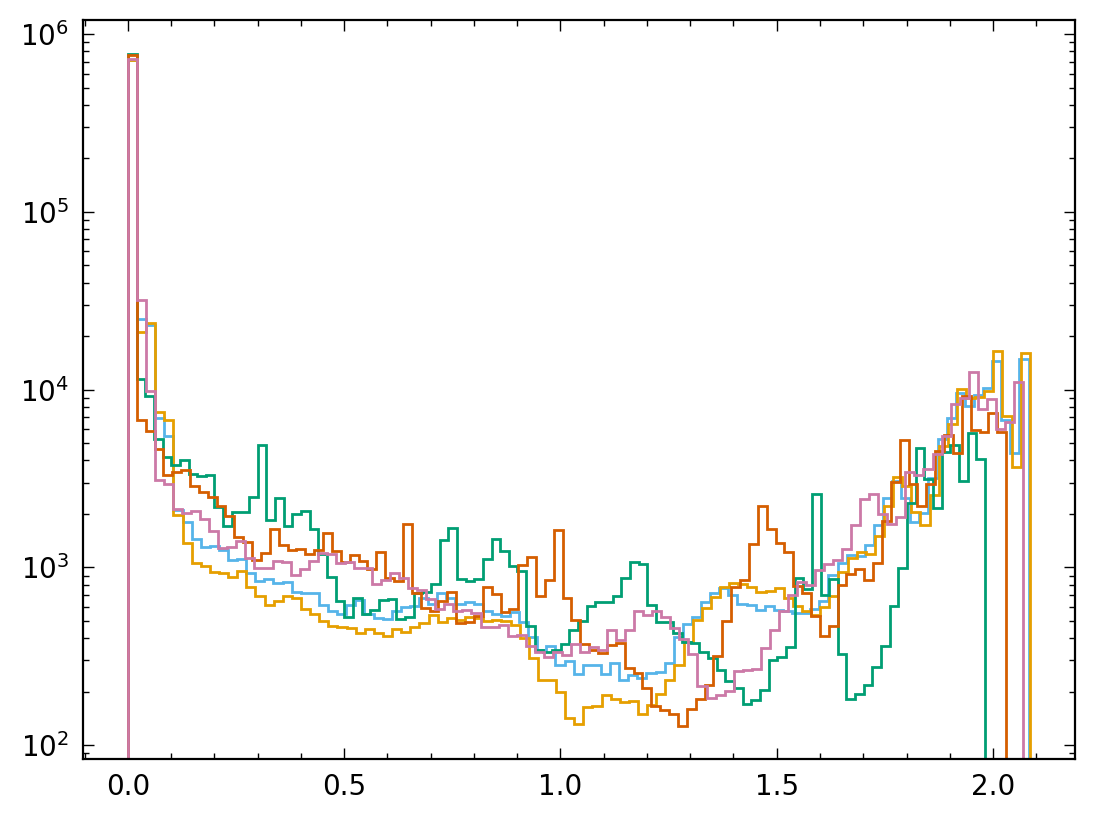

In [4]:
# Inspect distribution of observables
sel = 'peff_clearance'
for a in np.unique(clustered_mean_df.loc[(clustered_mean_df.b_I == b_C)][key_var].values):
    data = clustered_mean_df.loc[clustered_mean_df[key_var] == a]
    plt.hist(data[sel], bins = np.linspace(np.amin(data[sel]), np.amax(data[sel]), 100), histtype = 'step', log = True);

,antigenicity_over_harm,stim_pI,stim_pHI,stim_pHE
0,-6.000001,1.732615,1.226685,2.524440
1,-3.000001,2.725320,1.226685,2.524113
2,0.471658,0.217272,1.519880,2.135909
3,0.488371,0.279347,1.621096,2.138057
4,0.506171,0.343829,1.702827,2.137690
...,...,...,...,...
100,1.982271,2.655465,1.870394,2.328428
101,2.117271,2.736451,1.827951,2.412851
102,3.000001,0.022440,1.226685,2.567574
103,6.000001,0.184770,1.226685,2.537822


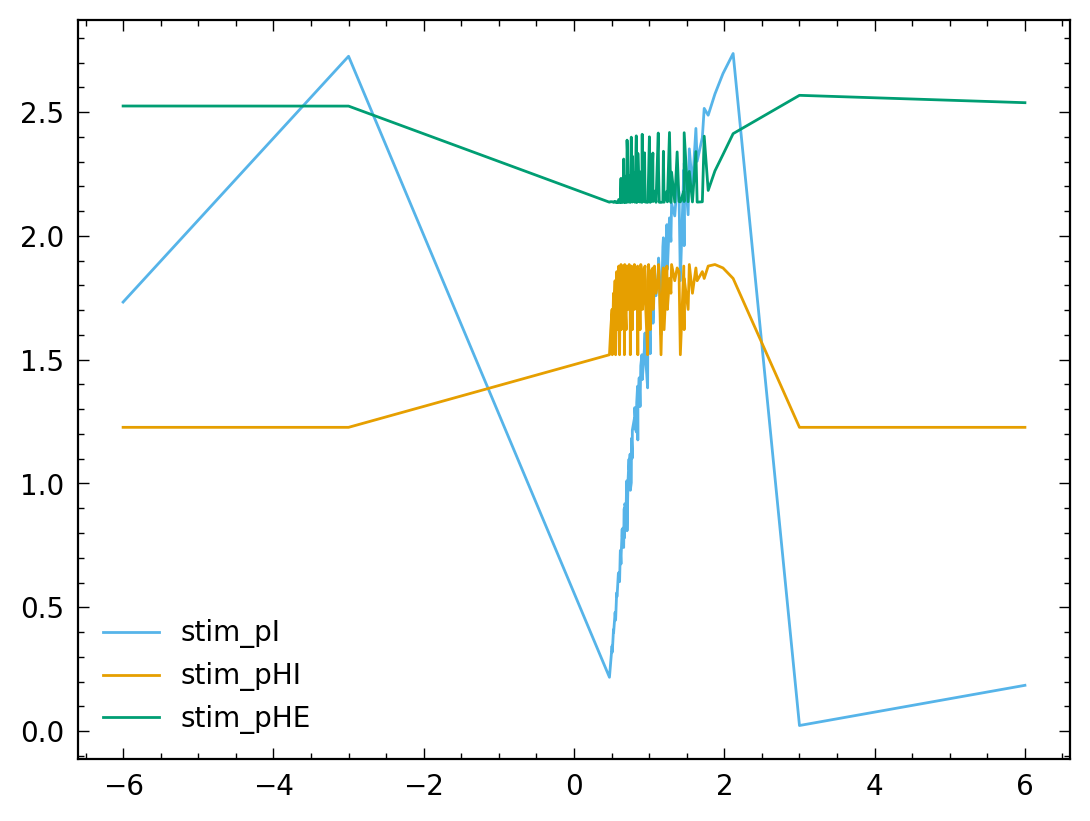

In [5]:
#norm_stim = clustered_mean_df.loc[(np.sum(np.abs(clustered_mean_df[reg_stim]), axis = 1) == 0)].groupby(key_var, as_index = False).mean()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
norm_stim = clustered_mean_df.groupby(key_var, as_index = False).max()[[key_var, 'stim_pI', 'stim_pHI', 'stim_pHE']]
with pd.option_context('display.max_columns', None):
    display(norm_stim)
    
plt.plot(norm_stim[key_var], norm_stim[['stim_pI', 'stim_pHI', 'stim_pHE']], label = ['stim_pI', 'stim_pHI', 'stim_pHE'])
plt.legend()

### Fit model to average data
The nonlinear sigmoid model does a good job on the data averaged over infections and marginalized over modules. This is the minimum we require.

fevals: 22
fevals: 16
fevals: 17
fevals: 14
fevals: 20
fevals: 28
fevals: 58
fevals: 21
fevals: 13
fevals: 8
fevals: 12
fevals: 13
fevals: 12
fevals: 9
fevals: 12
fevals: 13


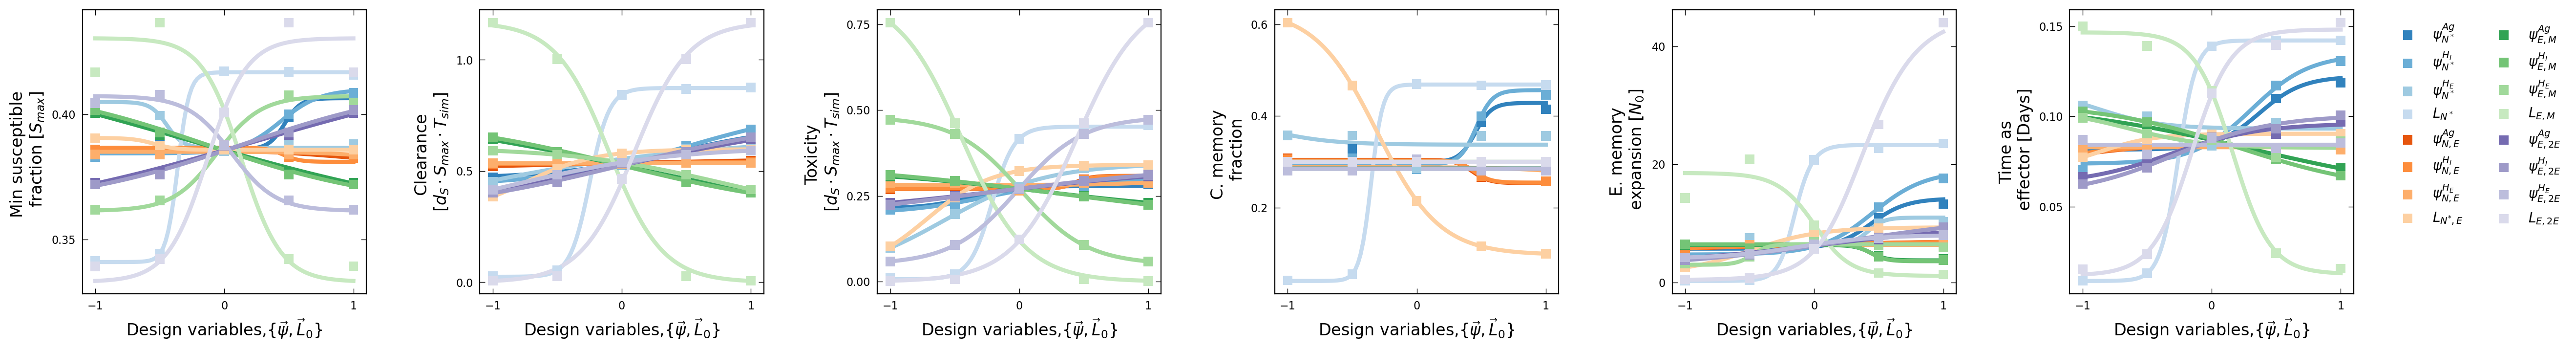

In [6]:
# Fit impact of regulatory parameters on performace: marginalizing over modules
fig, axs = plt.subplots(1, len(perf_vars), 
                              figsize=(len(perf_vars)**2 - len(perf_vars), 4), sharex=True, sharey=False)

for module_index in np.arange(0, len(modules)):
    reg_choice_label = modules[module_index]
    reg_choice = module_reg[reg_choice_label]
    zero_regs = np.concatenate([(module_reg[modules[u]] if u != module_index else []) for u in np.arange(0, len(modules))]).tolist()
    
    x_varname= key_var

    for j, p in enumerate(signal_classes):
        data_mean = clustered_mean_df.groupby(reg_choice[j], as_index = False).mean()
        
        for i, var in enumerate(perf_vars):
            im = axs[i].scatter(data_mean[reg_choice[j]]/np.amax(data_mean[reg_choice[j]]), 
                                (10**data_mean[var] - 1) if i == 4 or i == 5 else data_mean[var], 
                              marker = 's', s = 50, color = cmap_colors[module_index*len(reg_choice) + j], 
                                edgecolors = 'None',label = reg_label[module_index*len(reg_choice) + j ])

            y_max = np.max(data_mean[var].values)
            y_min = np.min(data_mean[var].values)
            y_std = np.std(data_mean[var].values)

            popt, pcov, infodict, _, _ = curve_fit(sigmoid_1d, data_mean[reg_choice[j]].values, data_mean[var].values, 
                                   p0 =(y_max - y_min, y_min, 0.0, 0.0),
                                   method = 'trf', 
                                   bounds = ([y_max - y_min, np.minimum(5*y_min, 0), -2*L0_max, -2*L0_max], 
                                             [5*y_max if y_max > 0 else y_std + 0.1, np.maximum(y_min, 0) + y_std + 0.1, 2*L0_max, 2*L0_max]),
                                   maxfev=10000,
                                   full_output = True)

            x = np.linspace(-np.max(data_mean[reg_choice[j]]), np.max(data_mean[reg_choice[j]]), 100)
            axs[i].plot(x/np.amax(x), (10**sigmoid_1d(x, *popt) - 1) if i == 4 or i == 5 else sigmoid_1d(x, *popt), 
                        linestyle='-',
                        linewidth = 3.0,
                        color = cmap_colors[module_index*len(reg_choice) + j], 
                        zorder = 0)

            if i == 0:
                print("fevals:", infodict['nfev'])

            if module_index + j == 0: 
                axs[i].minorticks_off()
                axs[i].yaxis.set_tick_params(labelbottom=True)
                axs[i].xaxis.set_tick_params(labelbottom=True)
                axs[i].tick_params(axis='both', which='major', labelsize=8)
                axs[i].set_box_aspect(1)
                axs[i].locator_params(axis='y', nbins=4)
                axs[i].locator_params(axis='x', nbins=4)
                axs[i].set_ylabel(perf_labels[i], fontsize = 12)
                axs[i].set_xlabel(r'Design variables,$\{\vec\psi, \vec L_0 \}$', fontsize = 12)

axs[-1].legend(bbox_to_anchor=(1.1, 1), fontsize=10, framealpha=0, ncol = 2)
fig.subplots_adjust(wspace=.4, hspace=.35)
plt.savefig('_figs/'+comment+'-'+'mean_regulation_trends_by_performance'+'.png', dpi=150, bbox_inches="tight")

In [7]:
del clustered_mean_df

### Fit model to individual infection scenarios and with all regulatory modules as variables

In [8]:
# Regress Performance measures on regulation parameters
num_cpu = 130
variables = reg
tol = 1e-6

def model(input, fit = "non-linear"):

    out = []
    infection = input[vir_vars].values[0]
    runtimes = str(np.round(infection, 3))+': '
    
    for i, perf in enumerate(perf_vars):
        # run regression
        start = time.time() # timestamp start
        
        if fit == "linear":
            input.loc[:,'dep_var'] = np.log(1 + input[perf].values) if 'Memory' in perf_labels[perf_vars.index(perf)] or 'magnitude' in perf_labels[perf_vars.index(perf)] else input[perf].values
            lr = smf.ols('dep_var ~ ' + ' + '.join(variables), data=input).fit()
    
            # save values
            out.append( (lr.params.values[0: 1 + len(variables)]).tolist() + np.sqrt(np.diag(lr.cov_params())).tolist() + infection.tolist() + [np.mean(input[perf].values), i] )
        else:
            y_max = np.max(input[perf].values)
            y_min = np.min(input[perf].values)
            y_std = np.std(input[perf].values)
            popt, pcov = curve_fit(sigmoid, input[variables].values, input[perf].values, 
                           p0 =[y_max - y_min, y_min] + len(variables)*[0.0] + num_modules*[0.0],
                           method = 'trf', 
                           bounds = ([np.minimum(0,y_max/2), np.minimum(0.0, 5*y_min)] + len(variables)*[-4.0*L0_max] + num_modules*[-4.0*L0_max], 
                                     [np.log10(2) if perf == "log_T_pEcyteM" else (y_max + tol), y_max + tol] + len(variables)*[4.0*L0_max] + num_modules*[4.0*L0_max]), 
                                   maxfev=100000,
                                   full_output = False)
            
            residuals = input[perf].values - sigmoid(input[variables].values, *popt)
            rmse = np.sqrt(np.mean(residuals**2))
            out.append(popt.tolist() + np.sqrt(np.diag(pcov)).tolist() + infection.tolist() + [np.mean(input[perf].values), 
                                                                                               np.max(input[perf].values), 
                                                                                               np.min(input[perf].values), 
                                                                                               np.median(input[perf].values), 
                                                                                               i, rmse, y_std, input['harm_pI_noprotection'].values[0],
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pI'].values), 
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHI'].values),
                                                                                               np.mean(input.loc[np.sum(np.abs(input[reg_stim]), axis = 1) == 0,'stim_pHE'].values)])

            # if i == 0:
            #     print("fevals:", infodict['nfev'])
        end = time.time() # timestamp start
        runtimes += (perf+ ' = ' + str((end - start)/3600)+' hrs, ')
        
    #print(runtimes)
    out_data = pd.DataFrame(np.vstack(out), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
    out_data['antigenicity_over_harm'] = antigenicity_over_harm(out_data)
    out_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/fits/'+comment+runs+'fit_'+str(np.round(infection, 3))+'.pkl')
    
    return np.vstack(out)

# Compile datasets
impact_data = pd.DataFrame(np.vstack(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(model)(input = data.groupby(vir_vars + variables, as_index=False).mean(), fit = "nonlinear") 
                                                                                                            for data in infection_scenarios)), 
                            columns = ['y_max', 'y_min'] \
                            + variables + [('intercept_' + j) for j in modules] \
                            + ['sigma_y_max', 'sigma_y_min'] + ['sigma_'+r  for r in variables] \
                            + [('sigma_intercept_' + j) for j in modules] \
                            + vir_vars \
                            + ['mean_perf', 'max_perf', 'min_perf', 'median_perf', 'perf_index', 'rmse', 'y_std', 'harm_pI_noprotection', 'stim_pI', 'stim_pHI', 'stim_pHE'])
impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [9]:
# # IF the above fails: Compile datasets
# num_cpu = 150
# file_list = [f for f in os.listdir(d) if comment in f]
# num_files = len(file_list)

# def import_fits(f,d):
    
#     file_path = os.path.join(d, f)
#     with open(file_path, 'rb') as filename:  
#         out = pickle.load(filename)

#     return out

# impact_data = pd.concat(Parallel(n_jobs = num_cpu, batch_size = max(int(n_virs/num_cpu),1))(delayed(import_fits)(f = file_name, d = d) 
#                                                                                                             for file_name in file_list))
# impact_data['antigenicity_over_harm'] = antigenicity_over_harm(impact_data)

# impact_data.to_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')

In [10]:
# View result
perf_choice = 0 # chose observable
impact_data = pd.read_pickle('/gscratch/scrubbed/oukogu/infoimmune/sim_output/no_cell_var/summary_stats/mean/'+comment+runs+'impact_data'+'.pkl')
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
0,0.987801,1.759592e-08,-0.097931,-0.041577,-0.203115,-0.601353,-1.156536,-1.639594,-0.039641,-0.393839,0.083765,0.057438,0.369580,0.728971,-0.085262,-0.056374,-0.368557,-0.729540,6.381715,13.073342,5.373828,5.375980,0.000564,0.170506,0.033817,0.033680,0.033931,0.055009,4.394090,7.543759,1.079088,1.351550,0.008056,0.007904,0.010920,0.016379,0.008070,0.007903,0.010905,0.016394,0.292520,18.085034,0.171448,0.171499,0.01,10000000.0,0.0,10000.0,10.000000,10000000.0,0.0,0.952942,0.987800,0.061824,0.987798,0.0,0.117511,0.130001,0.000000,0.301030,0.649918,0.213961,NaN
6,0.987801,1.038524e-09,-0.112528,-0.061672,-0.288671,-0.557467,-0.113031,-3.862853,0.015246,-0.343577,0.100354,0.074328,0.376935,0.612297,-0.100169,-0.074486,-0.377427,-0.612370,5.443443,13.696873,4.396675,4.395718,0.000966,0.097016,0.023944,0.023774,0.024386,0.036076,0.217337,14.304794,0.210592,0.227812,0.008366,0.008214,0.011011,0.013214,0.008357,0.008207,0.011019,0.013208,0.184984,28.661286,0.100773,0.100710,0.01,10000000.0,0.0,10000.0,31.622777,10000000.0,0.0,0.923533,0.987800,0.010463,0.987792,0.0,0.177681,0.198730,0.000000,0.301030,0.649917,0.288364,NaN
12,0.987801,2.517220e-39,-0.114433,-0.068248,-0.345460,-0.516357,-0.121187,-2.925505,0.000483,-0.249546,0.124220,0.090361,0.376863,0.556486,-0.124505,-0.090346,-0.375929,-0.556803,4.703238,10.829091,3.834382,3.832828,0.001417,0.065955,0.018349,0.018209,0.019111,0.025030,0.147496,3.795997,0.142230,0.115638,0.008829,0.008628,0.011155,0.011930,0.008821,0.008617,0.011141,0.011923,0.128550,7.635971,0.073099,0.073047,0.01,10000000.0,0.0,10000.0,100.000000,10000000.0,0.0,0.890704,0.987800,0.002916,0.987773,0.0,0.229692,0.258905,0.000000,0.301030,0.649916,0.362251,NaN
18,0.987801,8.873379e-41,-0.118208,-0.083304,-0.390940,-0.484789,-0.118220,-3.103358,-0.000997,-0.173060,0.137873,0.093053,0.399091,0.521599,-0.138448,-0.092212,-0.399499,-0.521517,4.159516,10.531471,3.499367,3.499978,0.001845,0.052299,0.015424,0.015317,0.016589,0.019167,0.116783,3.633972,0.112871,0.073327,0.009415,0.009150,0.011868,0.011544,0.009422,0.009149,0.011874,0.011547,0.099356,7.291993,0.062289,0.062303,0.01,10000000.0,0.0,10000.0,316.227766,10000000.0,0.0,0.861482,0.987800,0.001289,0.987707,0.0,0.272980,0.307578,0.000000,0.301030,0.649911,0.419539,NaN
24,0.987801,2.186015e-36,-0.118424,-0.083658,-0.398691,-0.468593,-0.129350,-2.904044,-0.005070,-0.107962,0.133156,0.080071,0.417206,0.495216,-0.132873,-0.080536,-0.417867,-0.495080,3.862641,10.665811,3.311771,3.311068,0.002168,0.047515,0.014291,0.014186,0.015652,0.016813,0.246666,6.540922,0.236407,0.132506,0.009733,0.009444,0.012453,0.011375,0.009728,0.009443,0.012463,0.011373,0.087729,13.130467,0.059238,0.059207,0.01,10000000.0,0.0,10000.0,1000.000000,10000000.0,0.0,0.843274,0.987800,0.000834,0.987497,0.0,0.297134,0.334177,0.000000,0.301030,0.649896,0.470813,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
750,0.885826,5.882511e-19,-0.001279,0.010003,-0.047132,-0.011886,-0.002088,-0.014085,-0.000132,-0.015665,0.009400,-0.000198,0.506948,0.781705,-0.011342,0.000060,-0.507234,-0.783242,2

#### Check the model goodness of the fit
The model does a pretty good job as the $R^2$ values for clearance, toxicity and memory are above 0.80.

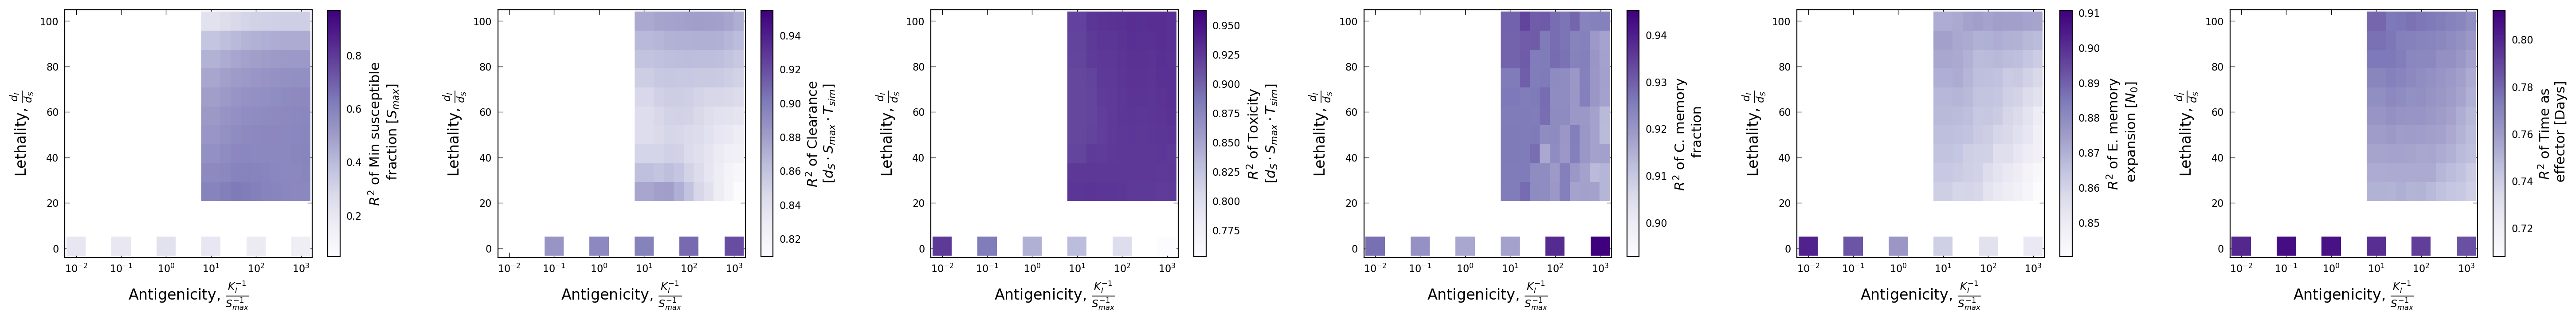

In [11]:
# Examine goodness of fit through R-squared
plots = [vir_vars[1], vir_vars[0]]
plot_labels = ["Antigenicity, "+r"$\frac{K_{I}^{-1}}{S_{max}^{-1}}$", "Lethality, "+r"$\frac{d_{I}}{d_{S}}$"]
size = 2750/np.sqrt(len(infection_scenarios))

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_r_sq = 1 - data.rmse**2/data.y_std**2
    z_label = r"$R^2$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = model_r_sq, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-r-squared'+'.png', dpi=150, bbox_inches="tight")

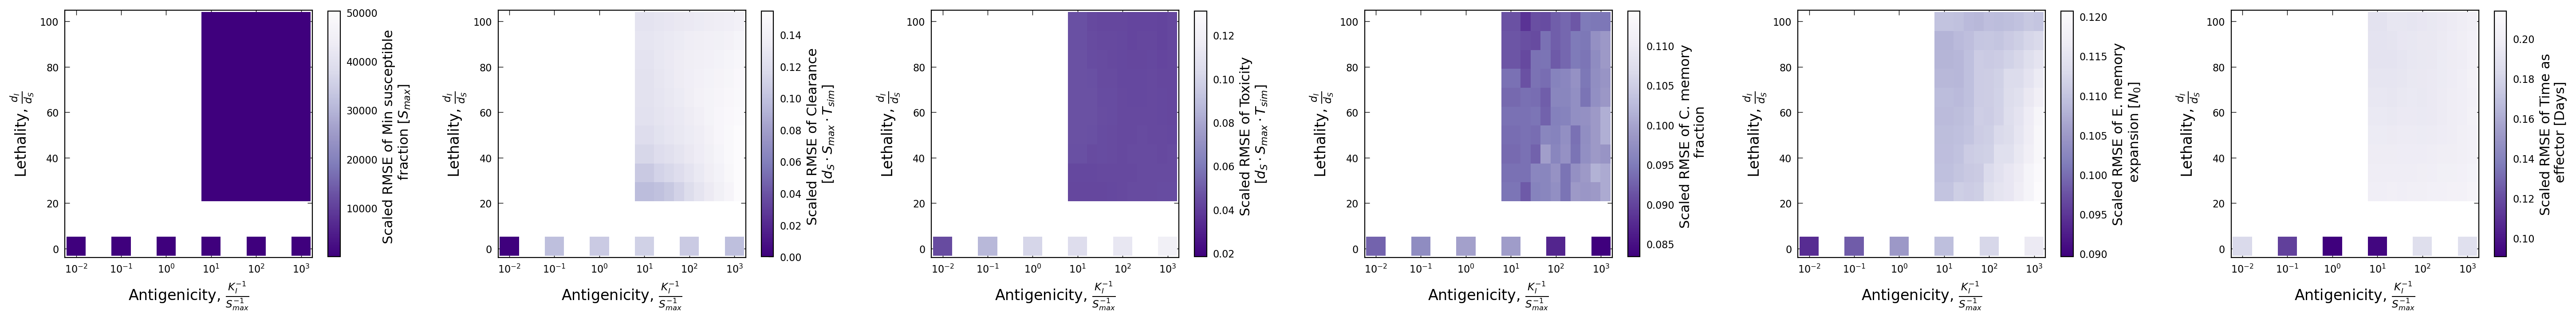

In [12]:
# Examine goodness of fit through scaled-RMSE
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    model_rmse_over_max = data.rmse/data.y_max
    z_label = "Scaled RMSE of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, 
                        c = model_rmse_over_max, cmap='Purples_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-scaled-rmse'+'.png', dpi=150, bbox_inches="tight")

Effector memory expansion appears challenging to fit based on the $R^2$ values. Looks much better when we look at scaled RMSE. Rationalize by observing tha effector memory expansion has non-monotonic dependence on some variables which can lead to a low variance estimate, and make the $R^2$ values look bad.

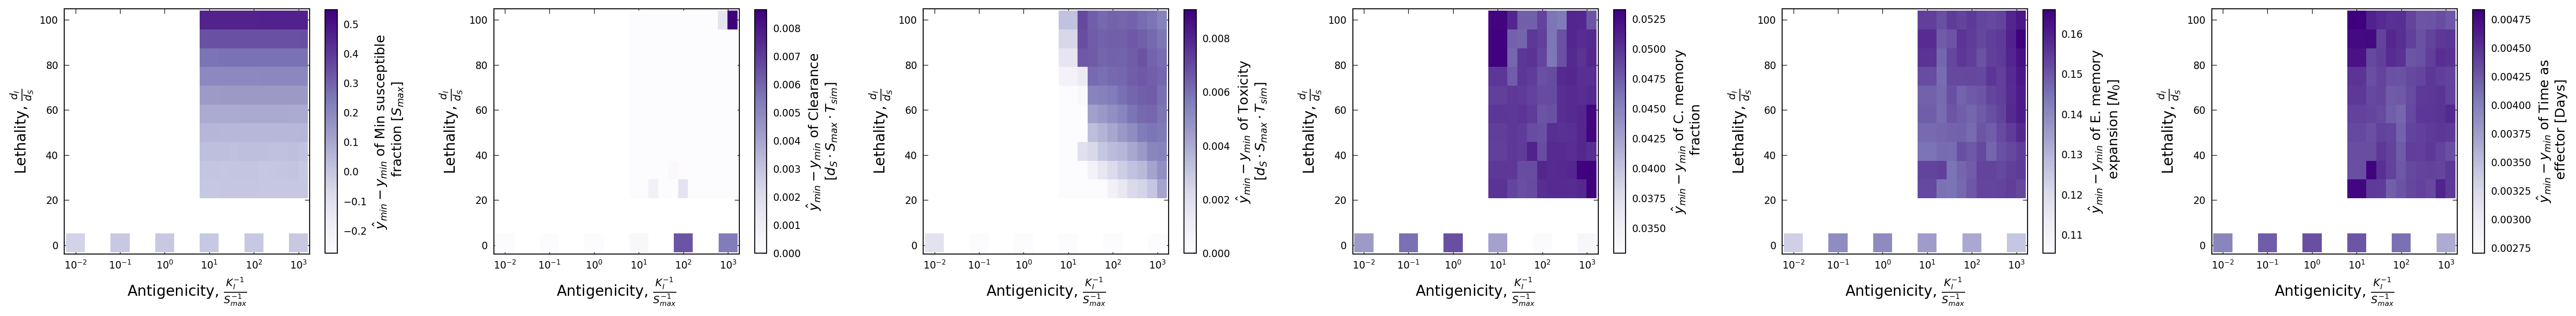

In [13]:
# Examine difference between observed and predicted minima
fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_{min} - y_{min}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = data.y_min - data.min_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_min'+'.png', dpi=150, bbox_inches="tight")

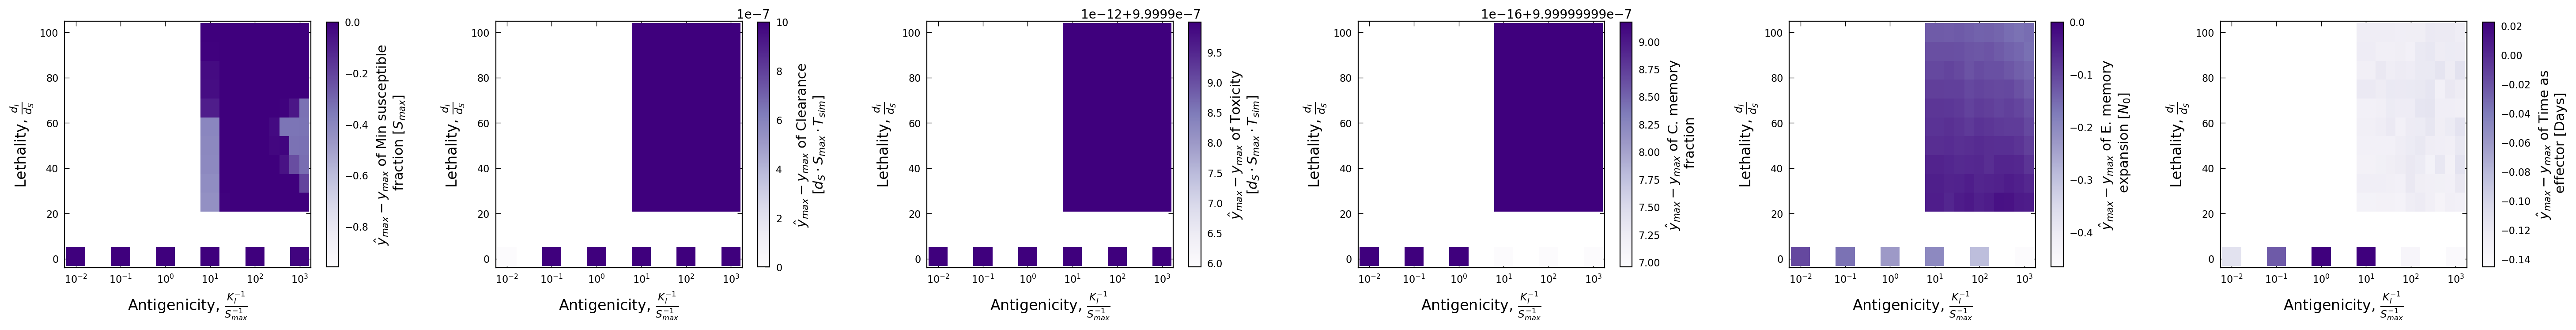

In [14]:
# Examine difference between observed and predicted maxima
plots = [vir_vars[1], vir_vars[0]]

fig, axs = plt.subplots(1, len(perf_vars), 
                          figsize=(len(perf_vars)**2, 2*len(perf_vars)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, perf in enumerate(perf_vars):
    data = impact_data[(impact_data.perf_index == i)]
    z_label = r"$\hat{y}_{max} - y_{max}$ of "+perf_labels[i]
    
    im = axs[i].scatter(data['S_0']/data[x_varname] if x_varname == 'K_I' else data[x_varname]/d_S,
                                 data['S_0']/data[y_varname] if y_varname == 'K_I' else data[y_varname]/d_S,
                      marker ='s', s = size, c = data.y_max - data.max_perf, cmap='Purples', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)

    cb = fig.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.30, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig.subplots_adjust(wspace=0.40, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

plt.savefig('_figs/'+comment+'-fits-y_max'+'.png', dpi=150, bbox_inches="tight")

The distribution of the values of the bias parameters gives us a sense of how well our simulations can explain variation due to that module. In this case the Naive to Memory module has a computed bias for clearance/toxicity that is at the maximum allowable. However the value is less extreme for memory formation. This suggests a strong bias towards high clearance/toxicity in this module.

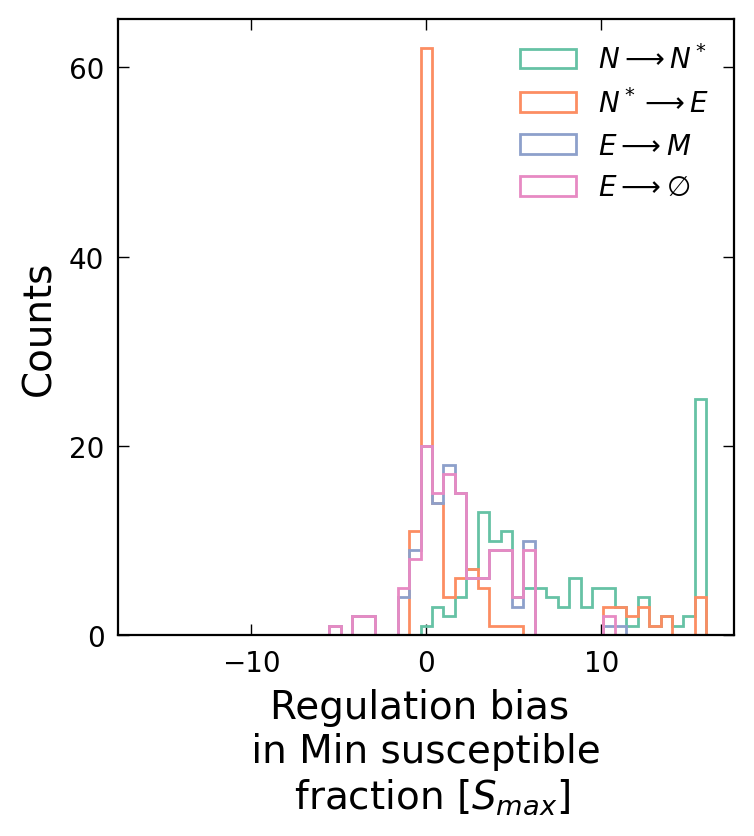

In [15]:
fig, axs = plt.subplots(figsize=(4,4), sharex=False, sharey=False)

cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
for i, r in enumerate(modules):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)]['intercept_'+r].values
    axs.hist(data, bins = np.linspace(-4*L0_max, 4*L0_max, 50), histtype = 'step', label = module_labels[i], color = cmap_colors[i], stacked = True);

axs.legend(fontsize = 10, ncol = 1)

axs.set_xlabel("Regulation bias \n in "+perf_labels[perf_choice], fontsize = 14)
axs.set_ylabel("Counts", fontsize = 14)
axs.set_box_aspect(1)
axs.minorticks_off()
axs.locator_params(axis='y', nbins=4)
axs.locator_params(axis='x', nbins=4)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

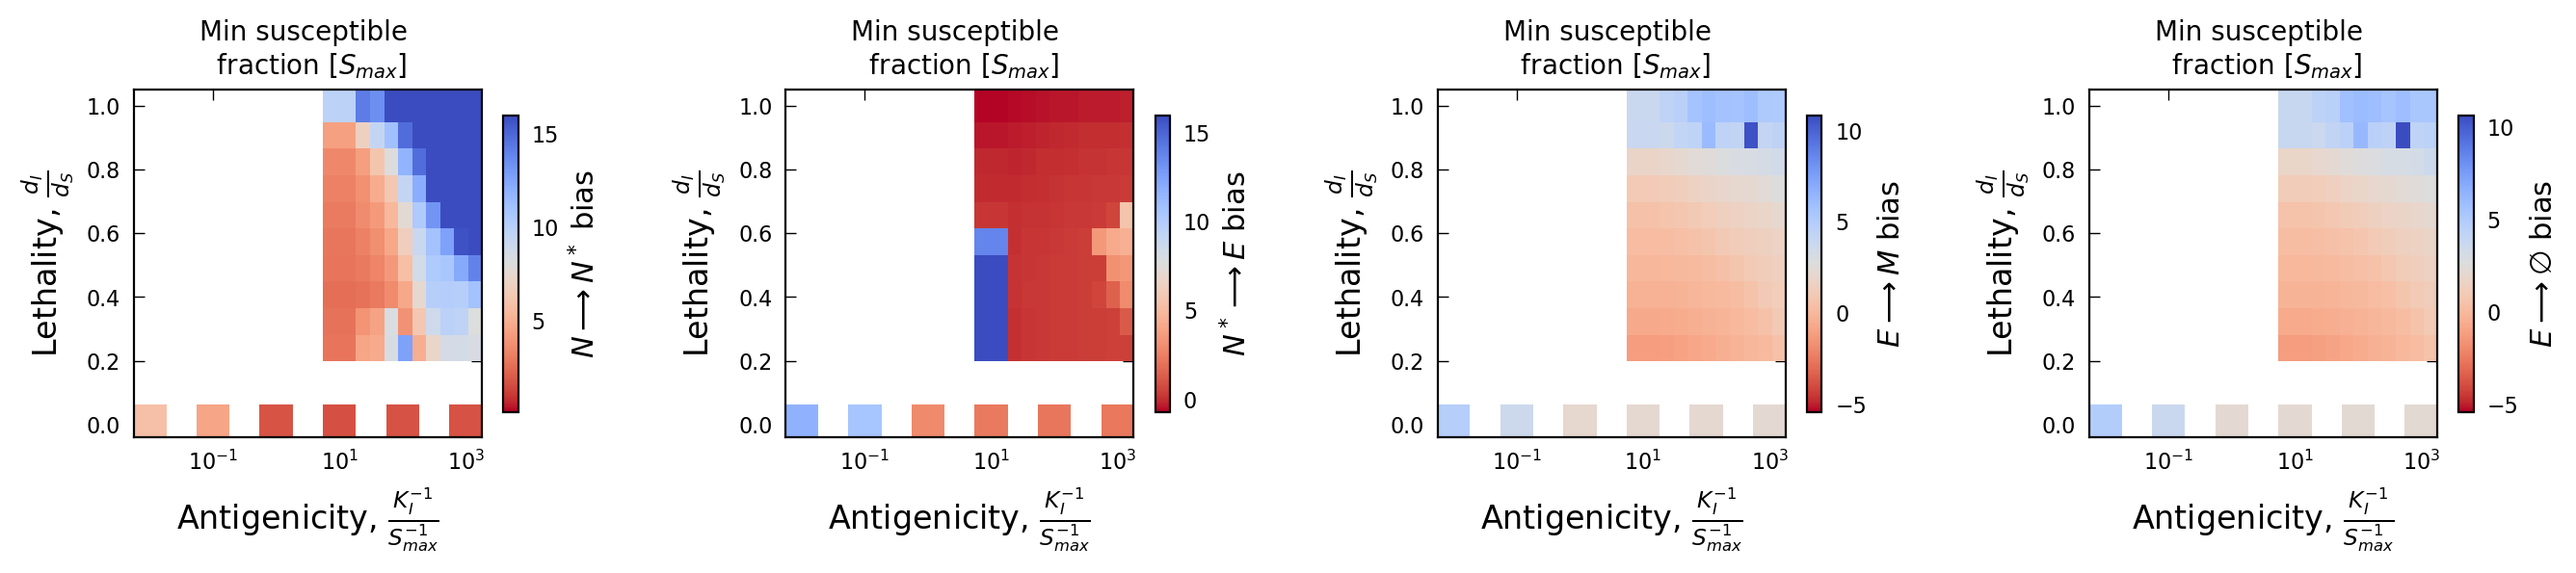

In [16]:
# Visualize optimal regulation
plots = [vir_vars[1], vir_vars[0]]
size = 1750/np.sqrt(len(infection_scenarios))

data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)]

fig_c, axs = plt.subplots(1, len(modules), 
                          figsize=(len(modules)**2, 2*len(modules)), sharex='row', sharey='col')

x_varname, y_varname = plots[0], plots[1]
for i, r in enumerate(modules):
    z_varname = 'intercept_'+r
    z_label = module_labels[i]+" bias"
    
    im = axs[i].scatter(S_0/data[x_varname] if x_varname == 'K_I' else data[x_varname],
                                 1/data[y_varname] if y_varname == 'K_I' else data[y_varname],
                      marker ='s', s = size, c = data[z_varname], cmap='coolwarm_r', edgecolors = 'None',# alpha = 0.8, 
                      norm = mpl.colors.Normalize())

    if x_varname == 'K_I':
        axs[i].semilogx()
    if y_varname == 'K_I':
        axs[i].semilogy()
        
    axs[i].minorticks_off()
    axs[i].set_box_aspect(1)
    axs[i].tick_params(axis='both', which='major', labelsize=8)
    axs[i].set_title(perf_labels[perf_choice], fontsize = 10.0)

    cb = fig_c.colorbar(im, ax=axs[i], orientation='vertical', shrink = 0.25, pad = 0.05)
    cb.set_label(z_label, fontsize = 11)
    cb.ax.tick_params(labelsize=8)
    
fig_c.subplots_adjust(wspace=.5, hspace=0.25)

for k, ax in enumerate(axs.flat):
    ax.set_xlabel(plot_labels[0], fontsize = 12)
    ax.set_ylabel(plot_labels[1], fontsize = 12)

# plt.savefig('_figs/'+comment+'-optimal-reg-average_prot_tox_hmap'+'.png', dpi=150, bbox_inches="tight")

These intercept values are important because they tell you what the value of the observable would be if we ran our processes, without regulation, at half their maximal characteristic rates. A positive value means that the half-max rate leads to above-median performance/cost. It would be useful to convert these to rates.

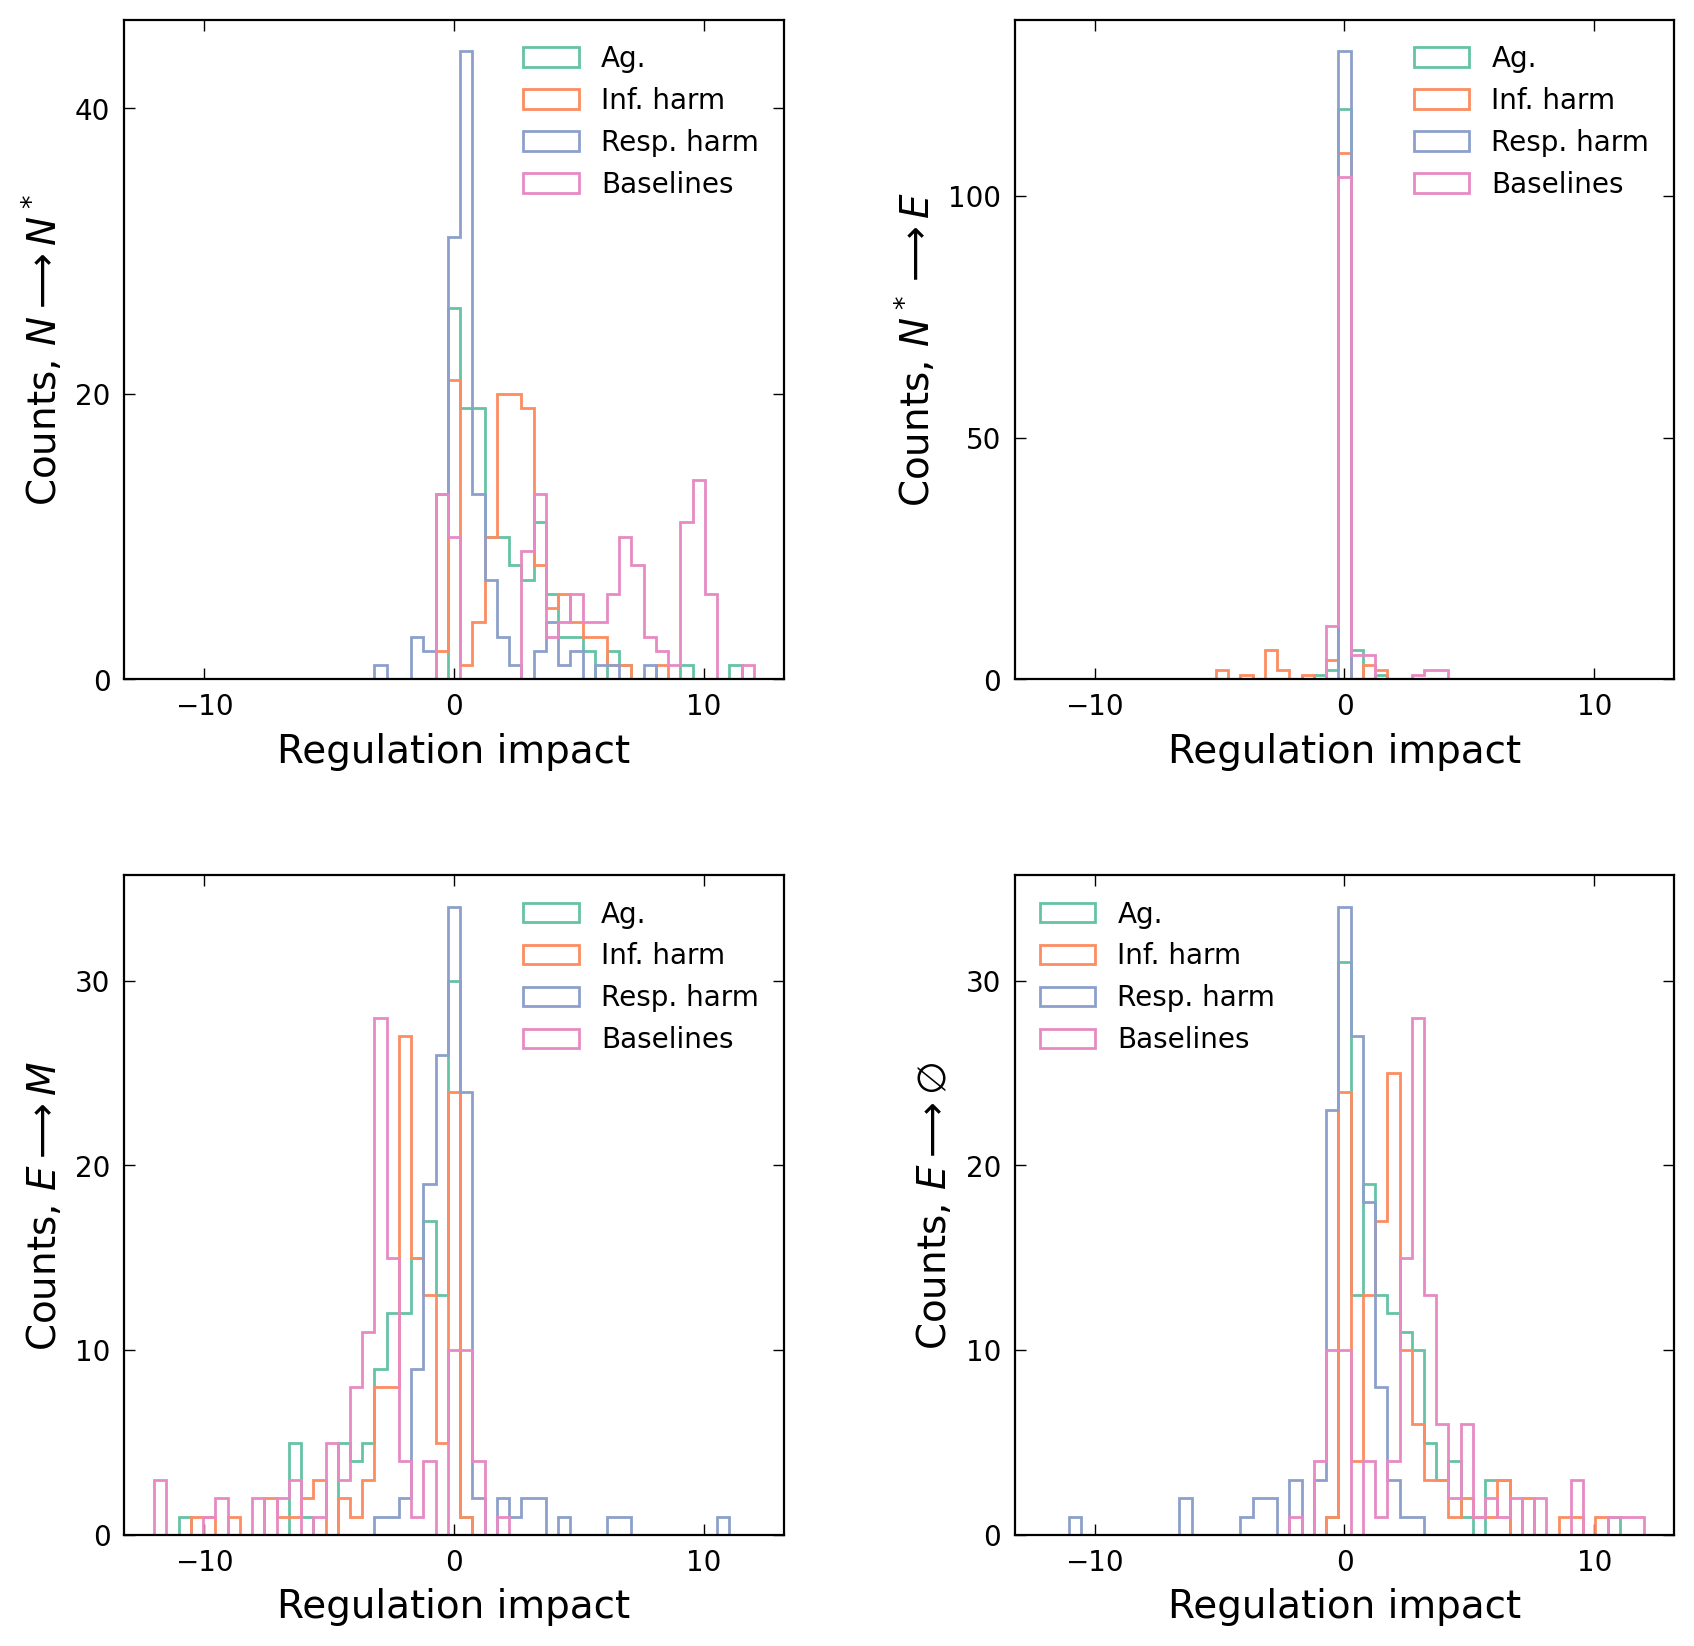

In [17]:
fig, axs = plt.subplots(2,2, figsize=(10,10), sharex=False, sharey=False)

for i, r in enumerate(reg):
    data = impact_data[(impact_data.perf_index == perf_choice)*(impact_data['K_H'] == K_H)][r].values
    module = i // num_modules
    cmap_colors = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']
    
    x, y = module // 2, module % 2
    axs[x,y].hist(data, bins = np.linspace(-3.0*L0_max, 3.0*L0_max, 50), histtype = 'step', label = signal_classes[i % num_modules], color = cmap_colors[i % num_modules], stacked = True);

    if (i % num_modules) == num_modules -1:
        axs[x,y].legend(fontsize = 10, ncol = 1)
    
        axs[x,y].set_xlabel("Regulation impact", fontsize = 14)
        axs[x,y].set_ylabel("Counts, "+module_labels[i // num_modules], fontsize = 14)
        axs[x,y].set_box_aspect(1)
        axs[x,y].minorticks_off()
        axs[x,y].locator_params(axis='y', nbins=4)
        axs[x,y].locator_params(axis='x', nbins=4)

fig.subplots_adjust(wspace=.35, hspace=.25)

#plt.savefig('_figs/'+comment+'-optimal-reg-average_utility'+'.png', dpi=150, bbox_inches="tight")

In [18]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == 0.0)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
0,0.987801,1.759592e-08,-0.097931,-0.041577,-0.203115,-0.601353,-1.156536,-1.639594,-0.039641,-0.393839,0.083765,0.057438,0.369580,0.728971,-0.085262,-0.056374,-0.368557,-0.729540,6.381715,13.073342,5.373828,5.375980,0.000564,0.170506,0.033817,0.033680,0.033931,0.055009,4.394090,7.543759,1.079088,1.351550,0.008056,0.007904,0.010920,0.016379,0.008070,0.007903,0.010905,0.016394,0.292520,18.085034,0.171448,0.171499,0.01,1.000000e+07,0.0,10000.0,10.000000,10000000.0,0.0,0.952942,0.9878,0.061824,0.987798,0.0,0.117511,0.130001,0.0,0.301030,0.649918,0.213961,NaN
6,0.987801,1.038524e-09,-0.112528,-0.061672,-0.288671,-0.557467,-0.113031,-3.862853,0.015246,-0.343577,0.100354,0.074328,0.376935,0.612297,-0.100169,-0.074486,-0.377427,-0.612370,5.443443,13.696873,4.396675,4.395718,0.000966,0.097016,0.023944,0.023774,0.024386,0.036076,0.217337,14.304794,0.210592,0.227812,0.008366,0.008214,0.011011,0.013214,0.008357,0.008207,0.011019,0.013208,0.184984,28.661286,0.100773,0.100710,0.01,1.000000e+07,0.0,10000.0,31.622777,10000000.0,0.0,0.923533,0.9878,0.010463,0.987792,0.0,0.177681,0.198730,0.0,0.301030,0.649917,0.288364,NaN
12,0.987801,2.517220e-39,-0.114433,-0.068248,-0.345460,-0.516357,-0.121187,-2.925505,0.000483,-0.249546,0.124220,0.090361,0.376863,0.556486,-0.124505,-0.090346,-0.375929,-0.556803,4.703238,10.829091,3.834382,3.832828,0.001417,0.065955,0.018349,0.018209,0.019111,0.025030,0.147496,3.795997,0.142230,0.115638,0.008829,0.008628,0.011155,0.011930,0.008821,0.008617,0.011141,0.011923,0.128550,7.635971,0.073099,0.073047,0.01,1.000000e+07,0.0,10000.0,100.000000,10000000.0,0.0,0.890704,0.9878,0.002916,0.987773,0.0,0.229692,0.258905,0.0,0.301030,0.649916,0.362251,NaN
18,0.987801,8.873379e-41,-0.118208,-0.083304,-0.390940,-0.484789,-0.118220,-3.103358,-0.000997,-0.173060,0.137873,0.093053,0.399091,0.521599,-0.138448,-0.092212,-0.399499,-0.521517,4.159516,10.531471,3.499367,3.499978,0.001845,0.052299,0.015424,0.015317,0.016589,0.019167,0.116783,3.633972,0.112871,0.073327,0.009415,0.009150,0.011868,0.011544,0.009422,0.009149,0.011874,0.011547,0.099356,7.291993,0.062289,0.062303,0.01,1.000000e+07,0.0,10000.0,316.227766,10000000.0,0.0,0.861482,0.9878,0.001289,0.987707,0.0,0.272980,0.307578,0.0,0.301030,0.649911,0.419539,NaN
24,0.987801,2.186015e-36,-0.118424,-0.083658,-0.398691,-0.468593,-0.129350,-2.904044,-0.005070,-0.107962,0.133156,0.080071,0.417206,0.495216,-0.132873,-0.080536,-0.417867,-0.495080,3.862641,10.665811,3.311771,3.311068,0.002168,0.047515,0.014291,0.014186,0.015652,0.016813,0.246666,6.540922,0.236407,0.132506,0.009733,0.009444,0.012453,0.011375,0.009728,0.009443,0.012463,0.011373,0.087729,13.130467,0.059238,0.059207,0.01,1.000000e+07,0.0,10000.0,1000.000000,10000000.0,0.0,0.843274,0.9878,0.000834,0.987497,0.0,0.297134,0.334177,0.0,0.301030,0.649896,0.470813,NaN
30,0.467904,9.875902e-01,0.503399,1.551494,3.503005,5.964056,0.133372,1.160315,0.005648,1.131293,-0.078760,-0.358418,-1.538419,-1.056493,0.088755,0.350577,1.513582,1.051486,3.300968,2.797717,-3.500449,-3.499853,0.001088,0.000016,0.010189,0.015471,0.026700,0.043368,0.004582,0.005617,0.004565,0.003327,0.001946,0.002049,0.003481,0.001809,0.001930,0.002028,0.003434,0.001795,0.023886,0.009109,0.004193,0.004169,0.01,1.000000e+08,0.0,10000.0,10.000000,10000000.0,0.0

In [19]:
with pd.option_context('display.max_columns', None):
    display(impact_data.loc[(impact_data.perf_index == perf_choice)*(impact_data.b_I == b_C)])

,y_max,y_min,psi_myc_I,psi_myc_HI,psi_myc_HE,L0_Na,psi_NE_I,psi_NE_HI,psi_NE_HE,L0_NE,psi_EM_I,psi_EM_HI,psi_EM_HE,L0_EM,psi_Edie_I,psi_Edie_HI,psi_Edie_HE,L0_Edie,intercept_Na,intercept_NE,intercept_EM,intercept_EE,sigma_y_max,sigma_y_min,sigma_psi_myc_I,sigma_psi_myc_HI,sigma_psi_myc_HE,sigma_L0_Na,sigma_psi_NE_I,sigma_psi_NE_HI,sigma_psi_NE_HE,sigma_L0_NE,sigma_psi_EM_I,sigma_psi_EM_HI,sigma_psi_EM_HE,sigma_L0_EM,sigma_psi_Edie_I,sigma_psi_Edie_HI,sigma_psi_Edie_HE,sigma_L0_Edie,sigma_intercept_Na,sigma_intercept_NE,sigma_intercept_EM,sigma_intercept_EE,d_I,K_I,b_I,K_H,N_0,S_0,I_0,mean_perf,max_perf,min_perf,median_perf,perf_index,rmse,y_std,harm_pI_noprotection,stim_pI,stim_pHI,stim_pHE,antigenicity_over_harm
690,0.000001,9.588349e-01,-0.121084,-0.035709,-0.011481,-0.052379,-0.126386,-0.024393,0.000220,-0.030185,0.278753,0.085612,-0.008585,0.088806,-0.278982,-0.085633,0.007876,-0.088394,0.770875,1.683324,1.229632,1.226782,0.051227,0.016502,0.009296,0.003226,0.001993,0.004001,0.024930,0.005875,0.003565,0.006083,0.010091,0.003864,0.002465,0.003233,0.010107,0.003864,0.002458,0.003221,0.104382,0.241742,0.047210,0.047196,0.01,10000.0,0.1,10000.0,10.0,10000000.0,1000000.0,0.633313,0.958834,0.602831,0.602833,0.0,0.073650,0.084575,2.651379,2.654886,1.183109,0.249519,-3.000001
696,0.967188,5.973755e-01,15.999856,5.469946,-1.535309,2.742336,-15.999745,-4.680019,-0.008898,-0.452807,-1.702942,-0.482562,2.351617,-0.174381,1.588147,0.445219,-2.140528,0.163412,3.081049,3.559329,-0.939208,-1.009033,0.008216,0.000246,0.906400,0.342820,0.160566,0.130284,2.157083,0.689256,0.234628,0.094439,0.060664,0.030873,0.076184,0.003854,0.052860,0.027614,0.064740,0.003742,0.225015,0.412628,0.023634,0.023131,0.01,10000.0,0.1,10000.0,100.0,10000000.0,1000000.0,0.616493,0.967187,0.048207,0.602847,0.0,0.098030,0.103517,2.651379,2.621541,1.163479,0.338845,-3.000001
702,0.968140,1.408870e-23,-0.087523,-0.019059,-0.226979,-0.063111,-0.374534,-0.052940,-0.002388,-0.047900,0.225837,0.054655,0.465824,0.163726,-0.225827,-0.054529,-0.466043,-0.163685,1.678092,2.217079,2.207282,2.206948,0.014731,0.038953,0.006617,0.004142,0.014785,0.004346,0.020596,0.006276,0.005782,0.003290,0.008265,0.005252,0.014302,0.005349,0.008265,0.005250,0.014309,0.005348,0.091443,0.088761,0.056570,0.056558,0.01,10000.0,0.1,10000.0,1000.0,10000000.0,1000000.0,0.576435,0.980195,0.002890,0.602831,0.0,0.152232,0.165719,2.651379,2.598076,1.146833,0.463967,-3.000001
708,0.000004,9.581147e-01,-0.080508,-0.052935,-0.018199,-0.047673,-0.087111,-0.038453,-0.000145,-0.035147,0.203628,0.141611,0.010159,0.101219,-0.203640,-0.139147,-0.009827,-0.101111,0.616967,1.840113,1.301433,1.298912,0.063031,0.016161,0.007194,0.004868,0.002214,0.004195,0.024577,0.011310,0.003885,0.010019,0.007410,0.005430,0.002474,0.003626,0.007429,0.005366,0.002469,0.003633,0.126362,0.334728,0.048440,0.048565,0.01,100000.0,0.1,10000.0,10.0,10000000.0,1000000.0,0.631761,0.958114,0.602688,0.602837,0.0,0.070150,0.081019,2.651379,1.666580,1.184314,0.245218,-6.000001
714,0.966933,5.977443e-01,11.482907,8.197764,-2.711307,3.149897,-14.401875,-5.043623,0.037614,-0.500004,-1.247874,-0.838119,2.156626,-0.160502,1.157048,0.779470,-1.958282,0.152851,3.559337,3.298567,-1.070791,-1.143030,0.009771,0.000248,0.886957,0.656563,0.278222,0.220049,1.975399,0.769186,0.238179,0.083893,0.052409,0.041154,0.076809,0.004289,0.045855,0.036400,0.065232,0.004196,0.374505,0.357960,0.027811,0.027505,0.01,100000.0,0.1,10000.0,100.0,10000000.0,1000000.0,0.613734,0.966932,0.048259,0.602866,0.0,0.098185,0.102088,2.651379,1.633220,1.164046,0.335851,-6.000001
720,0.979557,1.251309e-16,-0.064567,-0.026787,-0.217611,-0.077154,-0.247496,-0.092809,-0.003906,-0.059970,0.152879,0.088944,0.446329,0.186195,-0.152873,-0.088397,-0.446743,-0.186249,1.659830,2.135846,2.160659,2.160760,0.016610,0.033431,0.005451,0.004282,0.013572,0.005017,0.020235,0.008962,0.005842,0.005391,0.006387,0.005482,0.012581,0.005466,0.006386,0.005476,0.012590,0.005466,0.087059,0.111568,0.051276,0.051263,